**Author:** Rutendo F. Sigauke


# Introduction

Human bidirectional regions from DBNascent were lifted over to the mouse genome using 447-way alignment from Zoonomia with halLiftover. Lifted over regions for each bidirectional region in the mouse genome that were within 1kb were merged to a contigous region.

The lifted over regions in the mouse genome were mapped to the closest called bidirectional region in DBNascent using bedtools closest.

Mouse bidirectional regions within 1kb of the mouse lifted regions that were with greater 100bp were kept. Matched human and mouse bidirectional regions that were transcribed at a level greater than 1TPM in at least one sample were selected as conserved. 


# Load libraries

In [1]:
library(data.table)
library(ggplot2)
library(cowplot)

# Import data 

## Bidirectionals called

In [4]:
hg38_bidirs <- data.table::fread("/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit/hg38_tfit_dreg_bidirectionals.bed")
colnames(hg38_bidirs) <- c('bidir_chrom','bidir_start','bidir_end',
                           'bidirs','bidir_score','bidir_strand')
#format used in the liftover process (easier to looping through each region)
hg38_bidirs$bidir_id <- paste0(hg38_bidirs$bidir_chrom,"_",
                              hg38_bidirs$bidir_start, "_",
                              hg38_bidirs$bidir_end)
#format used in the pair annotations (easier to read)
hg38_bidirs$bidir_id_colon <- paste0(hg38_bidirs$bidir_chrom,":",
                              hg38_bidirs$bidir_start, "-",
                              hg38_bidirs$bidir_end)
head(hg38_bidirs, 3)


bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,bidir_id,bidir_id_colon
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>
chr1,3917,4919,dreg,14,.,chr1_3917_4919,chr1:3917-4919
chr1,5632,6042,dreg,14,.,chr1_5632_6042,chr1:5632-6042
chr1,6132,6486,dreg,7,.,chr1_6132_6486,chr1:6132-6486


In [5]:
mm10_bidirs <- data.table::fread("/scratch/Shares/dowell/dbnascent/out/meta_analysis/mumerge/bidirectionals_dreg_tfit/mm10_tfit_dreg_bidirectionals.bed")
colnames(mm10_bidirs) <- c('bidir_chrom','bidir_start','bidir_end',
                           'bidirs','bidir_score','bidir_strand')
#format used in the liftover process (easier to looping through each region)
mm10_bidirs$bidir_id <- paste0(mm10_bidirs$bidir_chrom,"_",
                              mm10_bidirs$bidir_start, "_",
                              mm10_bidirs$bidir_end)
#format used in the pair annotations (easier to read)
mm10_bidirs$bidir_id_colon <- paste0(mm10_bidirs$bidir_chrom,":",
                              mm10_bidirs$bidir_start, "-",
                              mm10_bidirs$bidir_end)
head(mm10_bidirs, 3)

bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,bidir_id,bidir_id_colon
<chr>,<int>,<int>,<chr>,<int>,<chr>,<chr>,<chr>
chr1,6234,6612,dreg,4,.,chr1_6234_6612,chr1:6234-6612
chr1,6855,7341,dreg,1,.,chr1_6855_7341,chr1:6855-7341
chr1,7420,8220,dreg,1,.,chr1_7420_8220,chr1:7420-8220


## halLiftover Mouse regions from Human

In [6]:
#liftover file
mm10_from_hg38 <- data.table::fread("/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/mm10bidirs_mm10liftover_distances/mm10_from_hg38_all_bidirs.lifted.sorted.bed")
colnames(mm10_from_hg38) <- c('mm10_chrom','mm10_start','mm10_end',
                           'empty_col','hg38_bidir_id')

dim(mm10_from_hg38)
tail(mm10_from_hg38, 3)

[1] 588206      5

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id
<chr>,<int>,<int>,<lgl>,<chr>
chrY,90842629,90843223,NA,chrX_10473216_10475046
chrY,90843223,90843328,NA,chrX_10470372_10470868
chrY,90843818,90843982,NA,chrX_10469735_10469903


In [7]:
# get human coordinates for each hg38 region
mm10_from_hg38$hg38_chrom <- as.character(lapply(strsplit(mm10_from_hg38$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 1))
mm10_from_hg38$hg38_start <- as.numeric(as.character(lapply(strsplit(mm10_from_hg38$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 2)))
mm10_from_hg38$hg38_end <- as.numeric(as.character(lapply(strsplit(mm10_from_hg38$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 3)))
head(mm10_from_hg38, 3)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>
chr1,3007597,3007826,NA,chr8_25615651_25616001,chr8,25615651,25616001
chr1,3095261,3095576,NA,chr8_55609506_55610468,chr8,55609506,55610468
chr1,3097335,3098056,NA,chr8_55606896_55607282,chr8,55606896,55607282


In [8]:
# calculate region widths for lifted over mouse regions
mm10_from_hg38$mm10_width <- mm10_from_hg38$mm10_end - mm10_from_hg38$mm10_start
mm10_from_hg38$hg38_width <- mm10_from_hg38$hg38_end - mm10_from_hg38$hg38_start
mm10_from_hg38$width_difference <- mm10_from_hg38$hg38_width - mm10_from_hg38$mm10_width
head(mm10_from_hg38, 3)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,3007597,3007826,NA,chr8_25615651_25616001,chr8,25615651,25616001,229,350,121
chr1,3095261,3095576,NA,chr8_55609506_55610468,chr8,55609506,55610468,315,962,647
chr1,3097335,3098056,NA,chr8_55606896_55607282,chr8,55606896,55607282,721,386,-335


In [9]:
as.factor(unique(mm10_from_hg38$mm10_chrom))

[1] chr1                 chr10                chr11               
 [4] chr12                chr13                chr14               
 [7] chr15                chr16                chr17               
[10] chr18                chr19                chr1_GL456210_random
[13] chr1_GL456211_random chr1_GL456212_random chr1_GL456213_random
[16] chr1_GL456221_random chr2                 chr3                
[19] chr4                 chr4_GL456350_random chr4_JH584293_random
[22] chr4_JH584294_random chr5                 chr5_GL456354_random
[25] chr6                 chr7                 chr7_GL456219_random
[28] chr8                 chr9                 chrUn_GL456360      
[31] chrUn_GL456366       chrUn_GL456372       chrUn_GL456378      
[34] chrUn_GL456379       chrUn_GL456382       chrUn_GL456385      
[37] chrUn_GL456393       chrUn_JH584304       chrX                
[40] chrX_GL456233_random chrY                
41 Levels: chr1 chr1_GL456210_random ... chrY

In [10]:
#define the mouse chromosomes
mm10_chroms <- c(paste0("chr",seq(1,19,1)),
                 "chrX","chrY")
mm10_chroms

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chrX"  "chrY"

In [11]:
# get only lift over to main 21 chromosomes
mm10_from_hg38_bidirs <- mm10_from_hg38[mm10_from_hg38$mm10_chrom %in% mm10_chroms,]
dim(mm10_from_hg38_bidirs)
head(mm10_from_hg38_bidirs, 3)

[1] 587649     11

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,hg38_chrom,hg38_start,hg38_end,mm10_width,hg38_width,width_difference
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
chr1,3007597,3007826,NA,chr8_25615651_25616001,chr8,25615651,25616001,229,350,121
chr1,3095261,3095576,NA,chr8_55609506_55610468,chr8,55609506,55610468,315,962,647
chr1,3097335,3098056,NA,chr8_55606896_55607282,chr8,55606896,55607282,721,386,-335


## Normalized counts

In [12]:
##all mouse sample counts
mm10_norm_counts <- data.table::fread("/Users/rusi2317/projects/meta_analysis_qc/mm10/processed_data/counts/normalized/gene_bidir_tpm.tsv.gz")
dim(mm10_norm_counts)
tail(mm10_norm_counts, 3)

[1] 706917    756

chrom,start,stop,gene_transcript,score,strand,SRR8364243,SRR8364244,SRR8364245,SRR8364246,⋯,SRZ7184276,SRZ7184278,SRZ7184280,SRZ7184282,SRR5144955,SRR5144956,SRR5144957,SRR5144958,SRZ12179472,SRZ12179474
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chrY,90828615,90828811,chrY:90828615-90828811,40,.,22.96989,31.5495,19.83703,28.40446,⋯,0,0,0,0,0,0,1.790591,0,0,0
chrY,90830134,90830562,chrY:90830134-90830562,69,.,0.00000,0.0000,0.00000,0.00000,⋯,0,0,0,0,0,0,0.000000,0,0,0
chrY,90830562,90831000,chrY:90830562-90831000,69,.,0.00000,0.0000,0.00000,0.00000,⋯,0,0,0,0,0,0,0.000000,0,0,0


In [13]:
##all human sample counts
hg38_norm_counts <- data.table::fread("/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/counts/normalized_counts/gene_bidir_tpm.tsv.gz")
dim(hg38_norm_counts)
tail(hg38_norm_counts, 3)

[1] 876410   1651

chrom,start,stop,gene_transcript,score,strand,SRR7266931,SRR7266932,SRR7266933,SRR7266934,⋯,SRR3713716,SRR3713717,SRR3713718,SRR3713719,SRR8483105,SRR8483106,SRR8483107,SRR8483108,SRR8483109,SRR8483110
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chrY,25633930,25634690,chrY:25633930-25634690,1,.,0.0000000,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chrY,25639750,25640170,chrY:25639750-25640170,1,.,0.0000000,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chrY,25738260,25738790,chrY:25738260-25738790,1,.,0.1481851,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


## Distances between mm10 bidirectionals and lifted mouse coordinates

In [14]:
#closest distance between lifted mouse and annotated bidirectionals
mm10_bidirs_liftover_distances <- data.table::fread("/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/mm10bidirs_mm10liftover_distances/mm10liftover_closest_mm10bidirs.bed")
colnames(mm10_bidirs_liftover_distances) <- c('mm10_chrom','mm10_start','mm10_end',
                                              'empty_col','hg38_bidir_id',
                                              'bidir_chrom','bidir_start','bidir_end',
                                              'bidirs','bidir_score','bidir_strand','distance')
mm10_bidirs_liftover_distances$mm10_bidir_id <- paste0(mm10_bidirs_liftover_distances$bidir_chrom, "_",
                                                      mm10_bidirs_liftover_distances$bidir_start, "_",
                                                      mm10_bidirs_liftover_distances$bidir_end)
dim(mm10_bidirs_liftover_distances)
head(mm10_bidirs_liftover_distances, 3)

[1] 608018     13

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,distance,mm10_bidir_id
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<chr>
chr1,3007597,3007826,NA,chr8_25615651_25616001,chr1,3014770,3015010,dreg,1,.,6945,chr1_3014770_3015010
chr1,3095261,3095576,NA,chr8_55609506_55610468,chr1,3119802,3120542,"tfit,dreg",2,.,24227,chr1_3119802_3120542
chr1,3097335,3098056,NA,chr8_55606896_55607282,chr1,3119802,3120542,"tfit,dreg",2,.,21747,chr1_3119802_3120542


In [15]:
#get width of mm10 lifted regions
mm10_bidirs_liftover_distances$mm10_width <- mm10_bidirs_liftover_distances$mm10_end - mm10_bidirs_liftover_distances$mm10_start


## Genome sizes

In [16]:
hg38_chrom_sizes <- read.table('/scratch/Shares/dowell/genomes/hg38/hg38.chrom.sizes.unsorted')
hg38_chroms <- hg38_chrom_sizes[1:24,]
hg38_chroms$chrs <- factor(hg38_chroms$V1, levels = hg38_chroms$V1)
head(hg38_chroms, 3)

,V1,V2,chrs
,<chr>,<int>,<fct>
1,chr1,248956422,chr1
2,chr2,242193529,chr2
3,chr3,198295559,chr3


In [17]:
mm10_chrom_sizes <- read.table('/scratch/Shares/dowell/genomes/mm10/mm10.chrom.sizes')
mm10_chroms <- mm10_chrom_sizes[1:21,]
mm10_chroms$chrs <- factor(mm10_chroms$V1, levels = mm10_chroms$V1)
head(mm10_chroms,3)

,V1,V2,chrs
,<chr>,<int>,<fct>
1,chr1,195471971,chr1
2,chr2,182113224,chr2
3,chr3,160039680,chr3


## Bidirectional categories

In [66]:
hg38_transcript_cate <- data.table::fread("/scratch/Shares/dowell/dbnascent/out/meta_analysis/specs_scores/hg38_all_classification.txt",
                                         header=FALSE)
colnames(hg38_transcript_cate) <- c("bidir_id_colon", "hg38_location")
hg38_transcript_cate$bidir_chr <- as.character(lapply(strsplit(hg38_transcript_cate$bidir_id_colon, 
                                                          ':'), 
                                                 `[`, 1))
hg38_transcript_cate$bidir_start_stop <- as.character(lapply(strsplit(hg38_transcript_cate$bidir_id_colon, 
                                                          ':'), 
                                                 `[`, 2))
hg38_transcript_cate$bidir_start <- as.character(lapply(strsplit(hg38_transcript_cate$bidir_start_stop, 
                                                          '-'), 
                                                 `[`, 1))
hg38_transcript_cate$bidir_stop <- as.character(lapply(strsplit(hg38_transcript_cate$bidir_start_stop, 
                                                          '-'), 
                                                 `[`, 2))
hg38_transcript_cate$bidir_id <- paste0(hg38_transcript_cate$bidir_chr,"_",
                                       hg38_transcript_cate$bidir_start,"_",
                                       hg38_transcript_cate$bidir_stop)

dim(hg38_transcript_cate)
tail(hg38_transcript_cate, 3)

[1] 947558      7

bidir_id_colon,hg38_location,bidir_chr,bidir_start_stop,bidir_start,bidir_stop,bidir_id
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chrY:56881721-56881941,intergenic,chrY,56881721-56881941,56881721,56881941,chrY_56881721_56881941
chrY:56883158-56883488,intergenic,chrY,56883158-56883488,56883158,56883488,chrY_56883158_56883488
chrY:56884695-56885095,intergenic,chrY,56884695-56885095,56884695,56885095,chrY_56884695_56885095


In [99]:
mm10_transcript_cate <- data.table::fread("/scratch/Users/rusi2317/projects/meta_analysis_qc_reviews/processed_data/bidirectional_classification/mm10_master_classification.txt",
                                         fill=TRUE)
dim(mm10_transcript_cate)
tail(mm10_transcript_cate, 3)

[1] 689779      7

V1,V2,V3,V4,V5,V6,V7
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chrY,90840861,90841211,dreg,25,.,intergenic
chrY,90843228,90843572,dreg,3,.,intergenic
chrY,90925972,90926362,dreg,1,.,intergenic


In [100]:
table(mm10_transcript_cate$V7)


               exonic intergenic   intronic   promoter 
     19163      31087     286219     330705      22605 

# Functions

## Summary statistics

In [19]:
get_summary_statistics <- function(counts_df, genenames, bidirnames){
    
    #1. transcript lenths
    transcript_lengths <- (counts_df$stop - counts_df$start) +1

    #2. number of columns in the dataframes
    ncolumns <- ncol(counts_df)

    
    ##get summary statistics for bed6+counts data.frame
    #3. transcript coordinated in bed6 format
    df_summary <- counts_df[,1:6]

    #4. get stats like length, st.dev, etc
    df_summary$length <- transcript_lengths
    df_summary$sum <- apply(counts_df[c(7:ncolumns)], 1, sum)
    df_summary$mean <- apply(counts_df[c(7:ncolumns)], 1, mean)
    df_summary$median <- apply(counts_df[c(7:ncolumns)], 1, median)
    df_summary$max <- apply(counts_df[c(7:ncolumns)], 1, max)
    df_summary$min <- apply(counts_df[c(7:ncolumns)], 1, min)
    df_summary$num_transcribed <- rowSums(counts_df[c(7:ncolumns)] != 0)
    df_summary$transcript_type <- ifelse(df_summary$gene_transcript %in% genenames,
                                                 "genes",
                                                 ifelse(df_summary$gene_transcript %in% bidirnames,
                                                        "bidirectional","NA"))
    return(df_summary)
    
}

# Summary of lift over regions

## All lifted over regions in human

In [20]:
##1: the number of lifted over coordinates (this is unique only)
nrow(unique(mm10_from_hg38[,1:3])) #mouse lifted
length(unique(mm10_from_hg38$hg38_bidir_id)) #human bidirs

[1] 584662

[1] 523938

In [21]:
##2: the number for regions on chromosomes (annotated)
nrow(unique(mm10_from_hg38_bidirs[,1:3])) #mouse lifted
length(unique(mm10_from_hg38_bidirs$hg38_bidir_id)) #human bidirs

[1] 584108

[1] 523903

Getting the width distributions of lifted over regions. We see that there are some really short regions that need filtering.

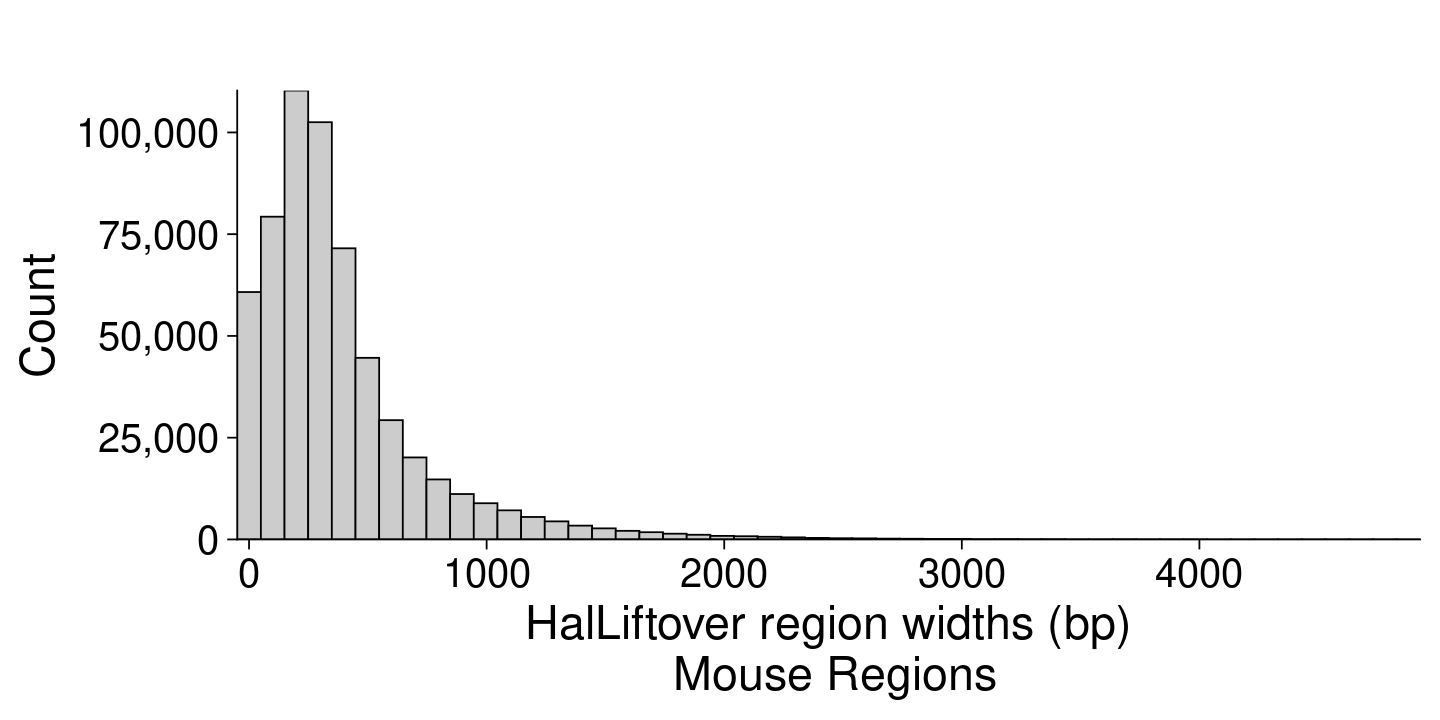

In [22]:
options(repr.plot.width=12, repr.plot.height=6)

mm10_lifted_regions_width_plot <- ggplot(mm10_from_hg38_bidirs, aes(x = mm10_width)) + 
geom_histogram(color="black", fill="gray80", bins=50) +
theme_cowplot(24) + 
scale_x_continuous(expand = c(0, 0))+
scale_y_continuous(expand = c(0, 0),
                  labels = scales::comma) +
ggtitle(" ") +
xlab("HalLiftover region widths (bp)\n Mouse Regions") +
ylab("Count") +
theme(plot.title = element_text(hjust = 0.5)) +
theme(plot.title = element_text(hjust = 0.5, face="plain"),
      title = element_text(size = 28), 
      axis.title = element_text(size = 28), 
      axis.text.x = element_text(size = 24),
      axis.text.y = element_text(size = 24)) 

mm10_lifted_regions_width_plot

In [23]:
# remove regions with less than 100bp (the lower limit we use for bidirectional calls is 150)
# NOTE: since we so not expect a one-one single alignment, adding a 50bp buffer 
mm10_from_hg38_bidirs_long <- subset(mm10_from_hg38_bidirs, mm10_width >=100)


In [24]:
##3: number of longer that 100bp region on chromosomes
nrow(unique(mm10_from_hg38_bidirs_long[, 1:3])) #mouse lifted
length(unique(mm10_from_hg38_bidirs_long$hg38_bidir_id)) #human bidirs

[1] 487334

[1] 454463

In [25]:
hg38_n_lifted_bidirs_long <- length(unique(mm10_from_hg38_bidirs_long$hg38_bidir_id))
hg38_n_total_bidirs <- length(unique(hg38_bidirs$bidir_id))

print("HUMAN: Percent lifted (>100bp) from all bidirectionals")
(hg38_n_lifted_bidirs_long/hg38_n_total_bidirs)*100

[1] "HUMAN: Percent lifted (>100bp) from all bidirectionals"


[1] 53.62262

## Adding a distance and length filter for lifted regions

In [26]:
##4i: get the counts for close regions that are longer than 100bp
mm10_bidirs_liftover_distances_long_within1kb <- subset(mm10_bidirs_liftover_distances,
                                                        abs(distance) < 1000 & 
                                                        mm10_width >=100)
head(mm10_bidirs_liftover_distances_long_within1kb, 3)
nrow(unique(mm10_bidirs_liftover_distances_long_within1kb[,1:3])) # mouse lifted
length(unique(mm10_bidirs_liftover_distances_long_within1kb$hg38_bidir_id)) # human bidirs
length(unique(mm10_bidirs_liftover_distances_long_within1kb$mm10_bidir_id)) # mouse bidirs 

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,distance,mm10_bidir_id,mm10_width
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<chr>,<int>
chr1,3163652,3164243,NA,chr8_55581776_55581996,chr1,3164794,3165258,tfit,1,.,552,chr1_3164794_3165258,591
chr1,3210807,3211459,NA,chr8_55528129_55528795,chr1,3212420,3213000,dreg,1,.,962,chr1_3212420_3213000,652
chr1,3385675,3385929,NA,chr8_55394464_55394774,chr1,3385720,3386030,tfit,1,.,0,chr1_3385720_3386030,254


[1] 338632

[1] 323282

[1] 261301

In [27]:
mm10_n_lifted_bidirs_long_close <- length(unique(mm10_bidirs_liftover_distances_long_within1kb$mm10_bidir_id))
hg38_n_lifted_bidirs_long_close <- length(unique(mm10_bidirs_liftover_distances_long_within1kb$hg38_bidir_id))
mm10_n_total_bidirs <- length(unique(mm10_bidirs$bidir_id))
hg38_n_total_bidirs <- length(unique(hg38_bidirs$bidir_id))


print("MOUSE: Percent lifted (>100bp) and within 1kb of ALL annotated bidirectionals")
(mm10_n_lifted_bidirs_long_close/mm10_n_total_bidirs)*100

print("HUMAN: Percent lifted (>100bp) and within 1kb of ALL annotated bidirectionals")
(mm10_n_lifted_bidirs_long_close/hg38_n_total_bidirs)*100

[1] "MOUSE: Percent lifted (>100bp) and within 1kb of ALL annotated bidirectionals"


[1] 38.38513

[1] "HUMAN: Percent lifted (>100bp) and within 1kb of ALL annotated bidirectionals"


[1] 30.83121

## Requiring the matched regions be transcribed

### Get transcription levels summary

In [29]:
###########################
### Mouse sample counts ###
###########################

#1: convert dt to df
mm10_norm_counts_df <- as.data.frame(mm10_norm_counts) ##gene_bidir_tpm_df

#2: get the gene IDs
mm10_genes <- mm10_norm_counts_df[!mm10_norm_counts_df$gene_transcript 
                                         %in%
                                         mm10_bidirs$bidir_id_colon,]
                                         
#3: get summary statistics based on the filtered samples
mm10_norm_counts_summary <- get_summary_statistics(mm10_norm_counts_df,
                                                mm10_genes$gene_transcript,
                                                mm10_bidirs$bidir_id_colon)

#4: add bidirectional IDs
mm10_norm_counts_summary$bidir_id <- paste0(mm10_norm_counts_summary$chrom,"_",
                                           mm10_norm_counts_summary$start,"_",
                                           mm10_norm_counts_summary$stop)

dim(mm10_norm_counts_summary)
head(mm10_norm_counts_summary, 3)

[1] 706917     15

,chrom,start,stop,gene_transcript,score,strand,length,sum,mean,median,max,min,num_transcribed,transcript_type,bidir_id
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,chr1,3214481,3670748,Xkr4:NM_001011874.1,.,-,456268,188.705288,0.251607050,0.005835468,11.073279,0,726,genes,chr1_3214481_3670748
2,chr1,4343506,4359564,Rp1:NM_011283.2,.,-,16059,4.240391,0.005653855,0.000000000,0.446401,0,194,genes,chr1_4343506_4359564
3,chr1,4490927,4496604,Sox17:NM_011441.5,.,-,5678,387.605925,0.516807901,0.000000000,8.916668,0,314,genes,chr1_4490927_4496604


In [30]:
###########################
### Human sample counts ###
###########################

#1: convert dt to df
hg38_norm_counts_df <- as.data.frame(hg38_norm_counts) ##gene_bidir_tpm_df

#2: get gene IDs
hg38_genes <- hg38_norm_counts_df[!hg38_norm_counts_df$gene_transcript 
                                         %in%
                                         hg38_bidirs$bidir_id_colon,]
                                         
#3: get summary statistics based on the filtered samples
hg38_norm_counts_summary <- get_summary_statistics(hg38_norm_counts_df,
                                                hg38_genes$gene_transcript,
                                                hg38_bidirs$bidir_id_colon)

#4: add bidirectional IDs
hg38_norm_counts_summary$bidir_id <- paste0(hg38_norm_counts_summary$chrom,"_",
                                           hg38_norm_counts_summary$start,"_",
                                           hg38_norm_counts_summary$stop)

dim(hg38_norm_counts_summary)
head(hg38_norm_counts_summary, 3)

[1] 876410     15

,chrom,start,stop,gene_transcript,score,strand,length,sum,mean,median,max,min,num_transcribed,transcript_type,bidir_id
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,chr1,12623,14409,DDX11L1:NR_046018.2,.,+,1787,28.27579,0.01718893,0.0000000,2.775420,0,60,genes,chr1_12623_14409
2,chr1,14361,28620,WASH7P:NR_024540.1,.,-,14260,369.37914,0.22454659,0.1585788,2.657019,0,1499,genes,chr1_14361_28620
3,chr1,17368,17436,MIR6859-1:NR_106918.1,.,-,69,0.00000,0.00000000,0.0000000,0.000000,0,0,genes,chr1_17368_17436


### Filter transcribed regions

In [31]:
#get regions where there is transcription in at least 1 sample and total TPM > 1 
#mouse regions
mm10_norm_counts_summary_txpt <- subset(mm10_norm_counts_summary, sum > 1 &
                                        num_transcribed >= 1 & 
                                        transcript_type == "bidirectional")
dim(mm10_norm_counts_summary_txpt)

#human regions
hg38_norm_counts_summary_txpt <- subset(hg38_norm_counts_summary, sum > 1 & 
                                        num_transcribed >= 1 &
                                       transcript_type == "bidirectional")
dim(hg38_norm_counts_summary_txpt)

[1] 667614     15

[1] 841610     15

### Get lifted regions that are with 1KB of transcribed bidirectional

This is done for both the human and mouse bidirectional transcript

In [32]:
mm10_bidirs_liftover_distances_long_within1kb_transcribed <- mm10_bidirs_liftover_distances_long_within1kb[mm10_bidirs_liftover_distances_long_within1kb$mm10_bidir_id %in% mm10_norm_counts_summary_txpt$bidir_id &
                                                                                                           mm10_bidirs_liftover_distances_long_within1kb$hg38_bidir_id %in% hg38_norm_counts_summary_txpt$bidir_id,]

dim(mm10_bidirs_liftover_distances_long_within1kb_transcribed)
nrow(unique(mm10_bidirs_liftover_distances_long_within1kb_transcribed[,1:3])) # mouse lifted
length(unique(mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_bidir_id)) # human bidirs
length(unique(mm10_bidirs_liftover_distances_long_within1kb_transcribed$mm10_bidir_id)) # mouse bidirs 


[1] 354950     14

[1] 334794

[1] 320913

[1] 259594

In [33]:
mm10_n_lifted_bidirs_long_close_txpt <- length(unique(mm10_bidirs_liftover_distances_long_within1kb_transcribed$mm10_bidir_id))
hg38_n_lifted_bidirs_long_close_txpt <- length(unique(mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_bidir_id))
mm10_n_transcribed_bidirs <- length(unique(mm10_norm_counts_summary_txpt$bidir_id))
hg38_n_transcribed_bidirs <- length(unique(hg38_norm_counts_summary_txpt$bidir_id))

print("MOUSE: Percent lifted (>100bp) and within 1kb of annotated bidirectionals for transcribed regions")
(mm10_n_lifted_bidirs_long_close_txpt/mm10_n_transcribed_bidirs)*100

print("HUMAN: Percent lifted (>100bp) and within 1kb of annotated bidirectionals for transcribed regions")
(hg38_n_lifted_bidirs_long_close_txpt/hg38_n_transcribed_bidirs)*100

[1] "MOUSE: Percent lifted (>100bp) and within 1kb of annotated bidirectionals for transcribed regions"


[1] 38.88385

[1] "HUMAN: Percent lifted (>100bp) and within 1kb of annotated bidirectionals for transcribed regions"


[1] 38.13084

### Save the matched conserved regions

In [34]:
mm10_hg38_bidirs_conserverd <- unique(mm10_bidirs_liftover_distances_long_within1kb_transcribed[,c("hg38_bidir_id","mm10_bidir_id")])
dim(mm10_hg38_bidirs_conserverd)
head(mm10_hg38_bidirs_conserverd)

[1] 354563      2

hg38_bidir_id,mm10_bidir_id
<chr>,<chr>
chr8_55581776_55581996,chr1_3164794_3165258
chr8_55528129_55528795,chr1_3212420_3213000
chr8_55314054_55314832,chr1_3446898_3447330
chr8_55314054_55314832,chr1_3447518_3448918
chr12_68764650_68764928,chr1_3532714_3533146
chr12_68765030_68765390,chr1_3532714_3533146


In [35]:
##separate to bed like format
mm10_hg38_bidirs_conserverd_bed <- data.table(hg38_chrom = as.character(lapply(strsplit(mm10_hg38_bidirs_conserverd$hg38_bidir_id, '_'), `[`, 1)),
                                   hg38_start = as.numeric(lapply(strsplit(mm10_hg38_bidirs_conserverd$hg38_bidir_id, '_'), `[`, 2)),
                                   hg38_stop = as.character(lapply(strsplit(mm10_hg38_bidirs_conserverd$hg38_bidir_id, '_'), `[`, 3)),
                                   mm10_chrom = as.character(lapply(strsplit(mm10_hg38_bidirs_conserverd$mm10_bidir_id, '_'), `[`, 1)),
                                   mm10_start = as.numeric(lapply(strsplit(mm10_hg38_bidirs_conserverd$mm10_bidir_id, '_'), `[`, 2)),
                                   mm10_stop = as.character(lapply(strsplit(mm10_hg38_bidirs_conserverd$mm10_bidir_id, '_'), `[`, 3))
                                   )
dim(mm10_hg38_bidirs_conserverd_bed)
head(mm10_hg38_bidirs_conserverd_bed)

[1] 354563      6

hg38_chrom,hg38_start,hg38_stop,mm10_chrom,mm10_start,mm10_stop
<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
chr8,55581776,55581996,chr1,3164794,3165258
chr8,55528129,55528795,chr1,3212420,3213000
chr8,55314054,55314832,chr1,3446898,3447330
chr8,55314054,55314832,chr1,3447518,3448918
chr12,68764650,68764928,chr1,3532714,3533146
chr12,68765030,68765390,chr1,3532714,3533146


In [36]:
data.table::fwrite(mm10_hg38_bidirs_conserverd_bed,
                   "/scratch/Shares/dowell/dbnascent/out/meta_analysis/conserved_bidirectionals/hg38_mm10_conserved_bidirectional_min1tpm.txt",
                  sep='\t')

## Check locations of conserved regions

In [64]:
hg38_bidir_cate_counts <- as.data.frame(table(hg38_transcript_cate$location))
hg38_bidir_cate_counts

Var1,Freq
<fct>,<int>
coding,52910
exonic,45460
intergenic,319050
intronic,472398
noncoding,30916
promoter,26824


In [67]:
mm10_hg38_bidirs_conserverd_hg38location <- merge(mm10_hg38_bidirs_conserverd, 
                                             hg38_transcript_cate,
                                             by.x="hg38_bidir_id",
                                             by.y="bidir_id")
head(mm10_hg38_bidirs_conserverd_hg38location)


hg38_bidir_id,mm10_bidir_id,bidir_id_colon,hg38_location,bidir_chr,bidir_start_stop,bidir_start,bidir_stop
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
chr10_100000773_100001115,chr19_43930491_43930851,chr10:100000773-100001115,intronic,chr10,100000773-100001115,100000773,100001115
chr10_100001829_100002093,chr19_43931162_43931602,chr10:100001829-100002093,intronic,chr10,100001829-100002093,100001829,100002093
chr10_100006278_100006600,chr19_43937151_43937709,chr10:100006278-100006600,intronic,chr10,100006278-100006600,100006278,100006600
chr10_100007302_100007616,chr19_43937151_43937709,chr10:100007302-100007616,intronic,chr10,100007302-100007616,100007302,100007616
chr10_100009743_100010131,chr19_43940095_43940373,chr10:100009743-100010131,exonic,chr10,100009743-100010131,100009743,100010131
chr10_100014302_100014614,chr19_43943069_43943351,chr10:100014302-100014614,intergenic,chr10,100014302-100014614,100014302,100014614


In [69]:
conserved_hg38_bidir_cate_counts <- as.data.frame(table(unique(mm10_hg38_bidirs_conserverd_hg38location[, 
                                                      c("hg38_bidir_id","hg38_location")])$hg38_location))
conserved_hg38_bidir_cate_counts

Var1,Freq
<fct>,<int>
exonic,30723
intergenic,86961
intronic,194516
promoter,20533


In [71]:
conserved_hg38_bidir_cate_counts_tab <- merge(conserved_hg38_bidir_cate_counts,
                                              hg38_bidir_cate_counts, by="Var1")
conserved_hg38_bidir_cate_counts_tab$percent_lifted <- 100*(conserved_hg38_bidir_cate_counts_tab$Freq.x/conserved_hg38_bidir_cate_counts_tab$Freq.y)
conserved_hg38_bidir_cate_counts_tab



Var1,Freq.x,Freq.y,percent_lifted
<fct>,<int>,<int>,<dbl>
exonic,30723,45460,67.58249
intergenic,86961,319050,27.25623
intronic,194516,472398,41.17630
promoter,20533,26824,76.54712


In [85]:
conserved_hg38_bidir_cate_counts_tab$bidirs <- c("Exonic", "Intergenic", "Intronic","Promoter")
conserved_hg38_bidir_cate_counts_tab$bidirs <- factor(conserved_hg38_bidir_cate_counts_tab$bidirs, 
                                        levels =  c("Intergenic","Intronic","Exonic","Promoter"))
conserved_hg38_bidir_cate_counts_tab

Var1,Freq.x,Freq.y,percent_lifted,bidirs
<fct>,<int>,<int>,<dbl>,<fct>
exonic,30723,45460,67.58249,Exonic
intergenic,86961,319050,27.25623,Intergenic
intronic,194516,472398,41.17630,Intronic
promoter,20533,26824,76.54712,Promoter


In [86]:
sum(conserved_hg38_bidir_cate_counts_tab$Freq.x)

[1] 332733

In [87]:
sum(conserved_hg38_bidir_cate_counts_tab$Freq.y)

[1] 863732

In [103]:
conserved_hg38_bidir_cate_counts_tab[,2]

[1]  30723  86961 194516  20533

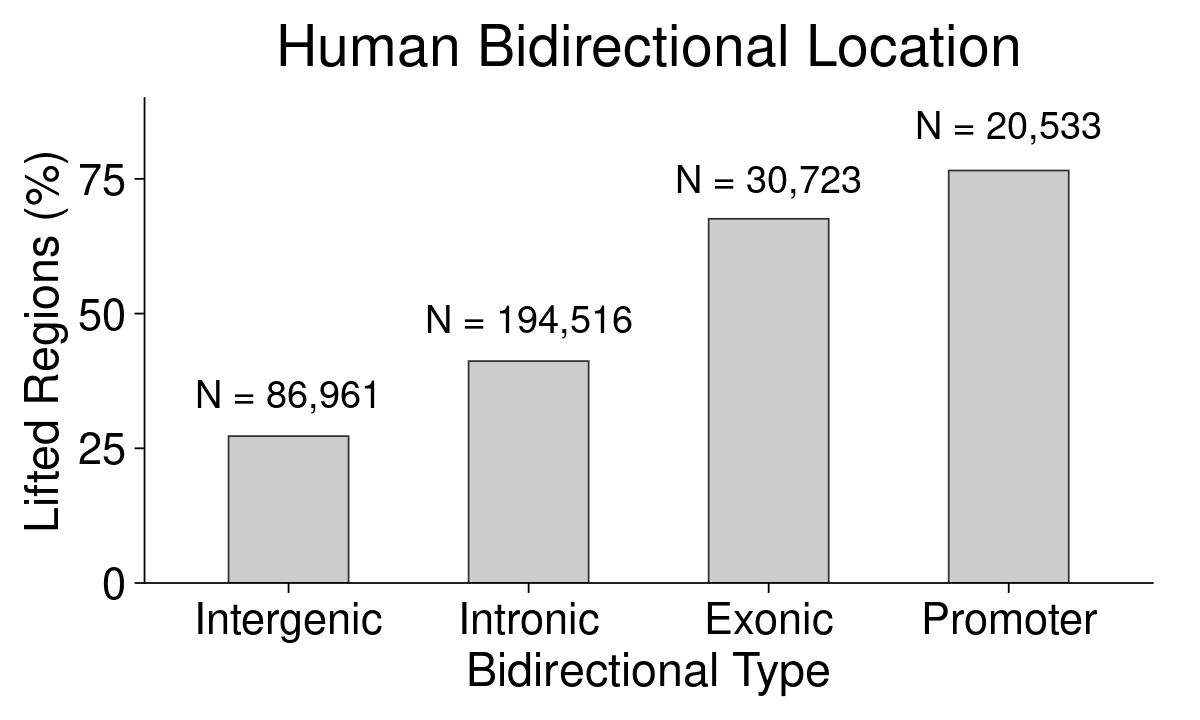

In [106]:
options(repr.plot.width=10, repr.plot.height=6)

conserved_hg38_bidir_cate_counts_barplot <- ggplot(conserved_hg38_bidir_cate_counts_tab, 
                                   aes(x=bidirs,
                                       y=percent_lifted)) +
geom_bar(stat="identity",
         fill="gray80",
         width=0.5,
          color='gray20') +
labs(title = "Human Bidirectional Location", 
       x = "Bidirectional Type",
       y = "Lifted Regions (%)") +
annotate("text", x=c(1,2,3,4),
         y=c(35,49,75,85), 
         #label= paste0("N =",format(conserved_hg38_bidir_cate_counts_tab$Freq.x, 
       #scientific = FALSE, big.mark = ',')),
         label=c("N = 86,961","N = 194,516",
                "N = 30,723", "N = 20,533"),
         size = 8) + 
theme_cowplot(24) +
scale_y_continuous(expand = c(0,0),limits=c(0,90)) +
theme(plot.title = element_text(hjust = 0.5, face="plain"),
      title = element_text(size = 30), 
      axis.title = element_text(size = 28),
      axis.text.y = element_text(size = 26),
      axis.text.x = element_text(size = 26)) +
theme(plot.margin = margin(0.5,1,0.5,0.5, "cm"))

conserved_hg38_bidir_cate_counts_barplot

In [108]:
ggsave(conserved_hg38_bidir_cate_counts_barplot, width = 10, height = 6,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/conserved_hg38_bidir_category_counts_barplot.pdf", 
       bg = "transparent")

ggsave(conserved_hg38_bidir_cate_counts_barplot, width = 10, height = 6,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/conserved_hg38_bidir_category_counts_barplot.png", 
       bg = "transparent")

## Plotting the transcription levels of conserved regions

In [37]:
#1: get max and min tpms for HUMAN bidirs 
mm10_bidirs_liftover_distances_transcribed_summ_hg38 <- merge(mm10_bidirs_liftover_distances_long_within1kb_transcribed,
                                                           hg38_norm_counts_summary_txpt[,c("bidir_id", "max","mean")],
                                                           by.x="hg38_bidir_id",
                                                            by.y="bidir_id")

#2: rename the max min for hg38
setnames(mm10_bidirs_liftover_distances_transcribed_summ_hg38, c("mean"), c("hg38_mean"))
setnames(mm10_bidirs_liftover_distances_transcribed_summ_hg38, c("max"), c("hg38_max"))

#3: get max and min tpms for MOUSE bidirs
mm10_bidirs_liftover_distances_transcribed_summ <- merge(mm10_bidirs_liftover_distances_transcribed_summ_hg38,
                                                           mm10_norm_counts_summary_txpt[,c("bidir_id", "max","mean")],
                                                           by.x="mm10_bidir_id",
                                                            by.y="bidir_id")

#4: rename the max min for mm10
setnames(mm10_bidirs_liftover_distances_transcribed_summ, c("mean"), c("mm10_mean"))
setnames(mm10_bidirs_liftover_distances_transcribed_summ, c("max"), c("mm10_max"))
dim(mm10_bidirs_liftover_distances_transcribed_summ)
head(mm10_bidirs_liftover_distances_transcribed_summ, 3)

[1] 354950     18

mm10_bidir_id,hg38_bidir_id,mm10_chrom,mm10_start,mm10_end,empty_col,bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,distance,mm10_width,hg38_max,hg38_mean,mm10_max,mm10_mean
<chr>,<chr>,<chr>,<int>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
chr10_100015595_100015907,chr12_88580309_88580663,chr10,100015626,100015989,NA,chr10,100015595,100015907,"tfit,dreg",46,.,0,363,152.62690,5.7260177,111.735095,3.9228257
chr10_100016242_100016618,chr12_88579553_88579859,chr10,100016459,100016932,NA,chr10,100016242,100016618,"tfit,dreg",46,.,0,473,51.63311,1.1250014,19.898568,0.7696677
chr10_100017542_100017862,chr12_88578099_88578557,chr10,100017898,100018362,NA,chr10,100017542,100017862,dreg,10,.,37,464,24.62894,0.3830339,3.800521,0.2464113


In [38]:
dim(unique(mm10_bidirs_liftover_distances_transcribed_summ[, c("hg38_bidir_id",
                                                              "hg38_mean",
                                                              "hg38_max")]))

[1] 320913      3

In [39]:
dim(unique(mm10_bidirs_liftover_distances_transcribed_summ[, c("mm10_bidir_id",
                                                              "mm10_mean",
                                                              "mm10_max")]))

[1] 259594      3

In [40]:
##Checking the number of regions match
dim(unique(mm10_bidirs_liftover_distances_transcribed_summ[, c("hg38_bidir_id",
                                                              "hg38_mean",
                                                              "hg38_max",
                                                               "mm10_bidir_id",
                                                              "mm10_mean",
                                                              "mm10_max")]))

[1] 354563      6

### Calculate correlations

#### Pearson's correlation coefficient

In [41]:
##Calculate pearson's correlation coefficiate 
max_pcc_res <- cor.test(mm10_bidirs_liftover_distances_transcribed_summ$hg38_max,
                        mm10_bidirs_liftover_distances_transcribed_summ$mm10_max)

max_pcc_res


	Pearson's product-moment correlation

data:  mm10_bidirs_liftover_distances_transcribed_summ$hg38_max and mm10_bidirs_liftover_distances_transcribed_summ$mm10_max
t = 32.259, df = 354948, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.0507859 0.0573462
sample estimates:
       cor 
0.05406663 


In [42]:
max_log_pcc_res <- cor.test(log(mm10_bidirs_liftover_distances_transcribed_summ$hg38_max, 2),
                            log(mm10_bidirs_liftover_distances_transcribed_summ$mm10_max,2))

max_log_pcc_res


	Pearson's product-moment correlation

data:  log(mm10_bidirs_liftover_distances_transcribed_summ$hg38_max, 2) and log(mm10_bidirs_liftover_distances_transcribed_summ$mm10_max, 2)
t = 269.36, df = 354948, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4092359 0.4146988
sample estimates:
      cor 
0.4119711 


In [48]:
mean_pcc_res <- cor.test(mm10_bidirs_liftover_distances_transcribed_summ$hg38_mean,
                        mm10_bidirs_liftover_distances_transcribed_summ$mm10_mean)

mean_pcc_res


	Pearson's product-moment correlation

data:  mm10_bidirs_liftover_distances_transcribed_summ$hg38_mean and mm10_bidirs_liftover_distances_transcribed_summ$mm10_mean
t = 204.52, df = 354948, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.3217430 0.3276289
sample estimates:
      cor 
0.3246891 


#### Spearman's correlation

In [44]:
max_rho_res <- cor.test(mm10_bidirs_liftover_distances_transcribed_summ$hg38_max,
                        mm10_bidirs_liftover_distances_transcribed_summ$mm10_max,
                        method="spearman")
max_rho_res

Warning message in cor.test.default(mm10_bidirs_liftover_distances_transcribed_summ$hg38_max, :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  mm10_bidirs_liftover_distances_transcribed_summ$hg38_max and mm10_bidirs_liftover_distances_transcribed_summ$mm10_max
S = 4.6953e+15, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3700448 


In [49]:
mean_rho_res <- cor.test(mm10_bidirs_liftover_distances_transcribed_summ$hg38_mean,
                        mm10_bidirs_liftover_distances_transcribed_summ$mm10_mean,
                        method="spearman")
mean_rho_res

Warning message in cor.test.default(mm10_bidirs_liftover_distances_transcribed_summ$hg38_mean, :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  mm10_bidirs_liftover_distances_transcribed_summ$hg38_mean and mm10_bidirs_liftover_distances_transcribed_summ$mm10_mean
S = 3.7126e+15, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.5018891 


#### Scatter plot of max values

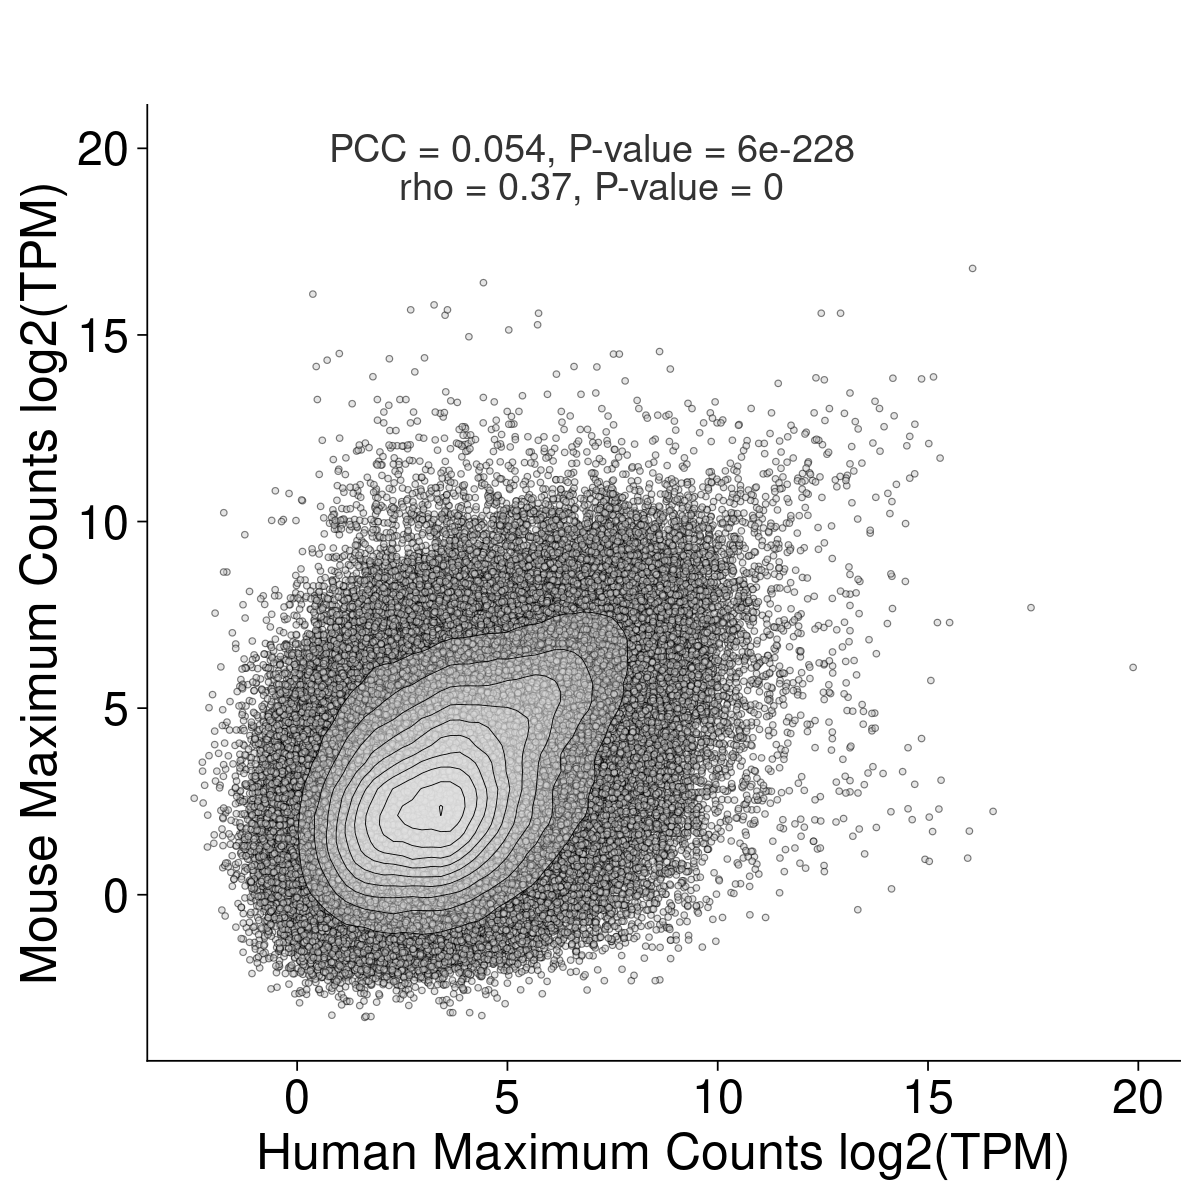

In [46]:
options(repr.plot.width=10, repr.plot.height=10)

txp_mm10bidirs_vs_lifted_max_scatterplot <- ggplot(mm10_bidirs_liftover_distances_transcribed_summ,
                               aes(x=log(hg38_max, 2),
                                   y=log(mm10_max, 2))) +
geom_point(shape=21,
           color="black", 
           alpha=0.5,
           fill="gray80") +
stat_density_2d(alpha=0.25,
                linewidth = 0.25,
                geom = "polygon", 
                colour="black", 
                fill='gray90') +
theme_cowplot(24) + 
annotate("text",
         x = 7,y = 20, 
         size=8, 
         label = paste0("PCC = ",signif(max_pcc_res$estimate, 2),
                        ", P-value = ",signif(max_pcc_res$p.value, 1)),
         color='gray20') +
annotate("text",
         x = 7,y = 19, 
         size=8, 
         label = paste0("rho = ",signif(max_rho_res$estimate, 2),
                        ", P-value = ",signif(max_rho_res$p.value, 2)),
         color='gray20') +
ggtitle(" ") +
xlab("Human Maximum Counts log2(TPM)") +
ylab("Mouse Maximum Counts log2(TPM)") +
labs(fill=" ") +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 36), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 28)) 

txp_mm10bidirs_vs_lifted_max_scatterplot

In [47]:
ggsave(txp_mm10bidirs_vs_lifted_max_scatterplot, width = 10, height = 10,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/txp_mm10bidirs_vs_lifted_max_scatterplot.pdf", 
       bg = "transparent")

ggsave(txp_mm10bidirs_vs_lifted_max_scatterplot, width = 10, height = 10,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/txp_mm10bidirs_vs_lifted_max_scatterplot.png", 
       bg = "transparent")

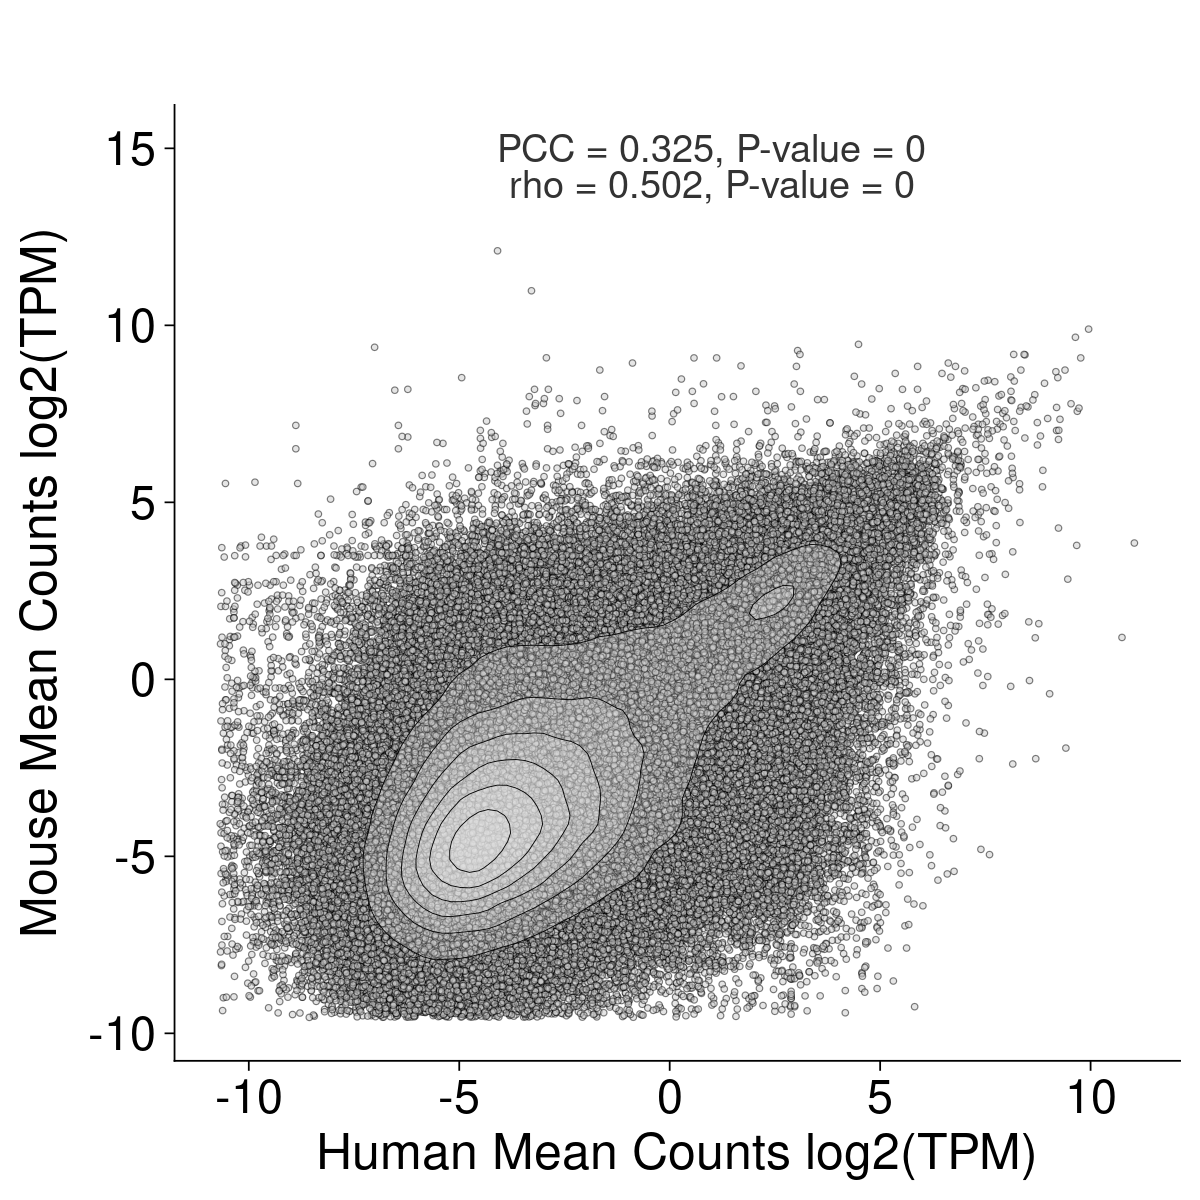

In [50]:
options(repr.plot.width=10, repr.plot.height=10)

txp_mm10bidirs_vs_lifted_mean_scatterplot <- ggplot(mm10_bidirs_liftover_distances_transcribed_summ,
                               aes(x=log(hg38_mean, 2),
                                   y=log(mm10_mean, 2))) +
geom_point(shape=21,
           color="black", 
           alpha=0.5,
           fill="gray80") +
stat_density_2d(alpha=0.25,
                linewidth = 0.25,
                geom = "polygon", 
                colour="black", 
                fill='gray90') +
theme_cowplot(24) + 
annotate("text",
         x = 1,y = 15, 
         size=8, 
         label = paste0("PCC = ",signif(mean_pcc_res$estimate, 3),
                        ", P-value = ",signif(mean_pcc_res$p.value, 3)),
         color='gray20') +
annotate("text",
         x = 1,y = 14, 
         size=8, 
         label = paste0("rho = ",signif(mean_rho_res$estimate, 3),
                        ", P-value = ",signif(mean_rho_res$p.value, 3)),
         color='gray20') +
ggtitle(" ") +
xlab("Human Mean Counts log2(TPM)") +
ylab("Mouse Mean Counts log2(TPM)") +
labs(fill=" ") +
theme(plot.title = element_text(hjust = 0.5),
      title = element_text(size = 36), 
      axis.title = element_text(size = 30), 
      axis.text = element_text(size = 28)) 

txp_mm10bidirs_vs_lifted_mean_scatterplot

In [51]:
ggsave(txp_mm10bidirs_vs_lifted_mean_scatterplot, width = 10, height = 10,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/txp_mm10bidirs_vs_lifted_mean_scatterplot.pdf", 
       bg = "transparent")

ggsave(txp_mm10bidirs_vs_lifted_mean_scatterplot, width = 10, height = 10,
       filename = "/Users/rusi2317/projects/meta_analysis_qc_reviews/paper_figures/txp_mm10bidirs_vs_lifted_mean_scatterplot.png", 
       bg = "transparent")

### Plotting the locations of lifted regions

In [55]:
head(mm10_bidirs_liftover_distances_long_within1kb_transcribed, 3)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,distance,mm10_bidir_id,mm10_width
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<chr>,<int>
chr1,3163652,3164243,NA,chr8_55581776_55581996,chr1,3164794,3165258,tfit,1,.,552,chr1_3164794_3165258,591
chr1,3210807,3211459,NA,chr8_55528129_55528795,chr1,3212420,3213000,dreg,1,.,962,chr1_3212420_3213000,652
chr1,3447116,3447711,NA,chr8_55314054_55314832,chr1,3446898,3447330,tfit,1,.,0,chr1_3446898_3447330,595


In [56]:
# get human coordinates for each hg38 region
mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_chrom <- as.character(lapply(strsplit(mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 1))
mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_start <- as.numeric(as.character(lapply(strsplit(mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 2)))
mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_end <- as.numeric(as.character(lapply(strsplit(mm10_bidirs_liftover_distances_long_within1kb_transcribed$hg38_bidir_id, 
                                                          '_'), 
                                                 `[`, 3)))
head(mm10_bidirs_liftover_distances_long_within1kb_transcribed, 3)

mm10_chrom,mm10_start,mm10_end,empty_col,hg38_bidir_id,bidir_chrom,bidir_start,bidir_end,bidirs,bidir_score,bidir_strand,distance,mm10_bidir_id,mm10_width,hg38_chrom,hg38_start,hg38_end
<chr>,<int>,<int>,<lgl>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>,<dbl>,<dbl>
chr1,3163652,3164243,NA,chr8_55581776_55581996,chr1,3164794,3165258,tfit,1,.,552,chr1_3164794_3165258,591,chr8,55581776,55581996
chr1,3210807,3211459,NA,chr8_55528129_55528795,chr1,3212420,3213000,dreg,1,.,962,chr1_3212420_3213000,652,chr8,55528129,55528795
chr1,3447116,3447711,NA,chr8_55314054_55314832,chr1,3446898,3447330,tfit,1,.,0,chr1_3446898_3447330,595,chr8,55314054,55314832


In [57]:
#https://stackoverflow.com/questions/9563711/r-color-palettes-for-many-data-classes

colors25 <- c(
  "dodgerblue2", "#E31A1C", # red
  "green4",
  "#6A3D9A", # purple
  "#FF7F00", # orange
  "black", "gold1",
  "skyblue2", "#FB9A99", # lt pink
  "palegreen2",
  "#CAB2D6", # lt purple
  "#FDBF6F", # lt orange
  "gray70", "khaki2",
  "maroon", "orchid1", "deeppink1", "blue1", "steelblue4",
  "darkturquoise", "green1", "yellow4", "yellow3",
  "darkorange4", "brown"
)
colors25

[1] "dodgerblue2"   "#E31A1C"       "green4"        "#6A3D9A"      
 [5] "#FF7F00"       "black"         "gold1"         "skyblue2"     
 [9] "#FB9A99"       "palegreen2"    "#CAB2D6"       "#FDBF6F"      
[13] "gray70"        "khaki2"        "maroon"        "orchid1"      
[17] "deeppink1"     "blue1"         "steelblue4"    "darkturquoise"
[21] "green1"        "yellow4"       "yellow3"       "darkorange4"  
[25] "brown"

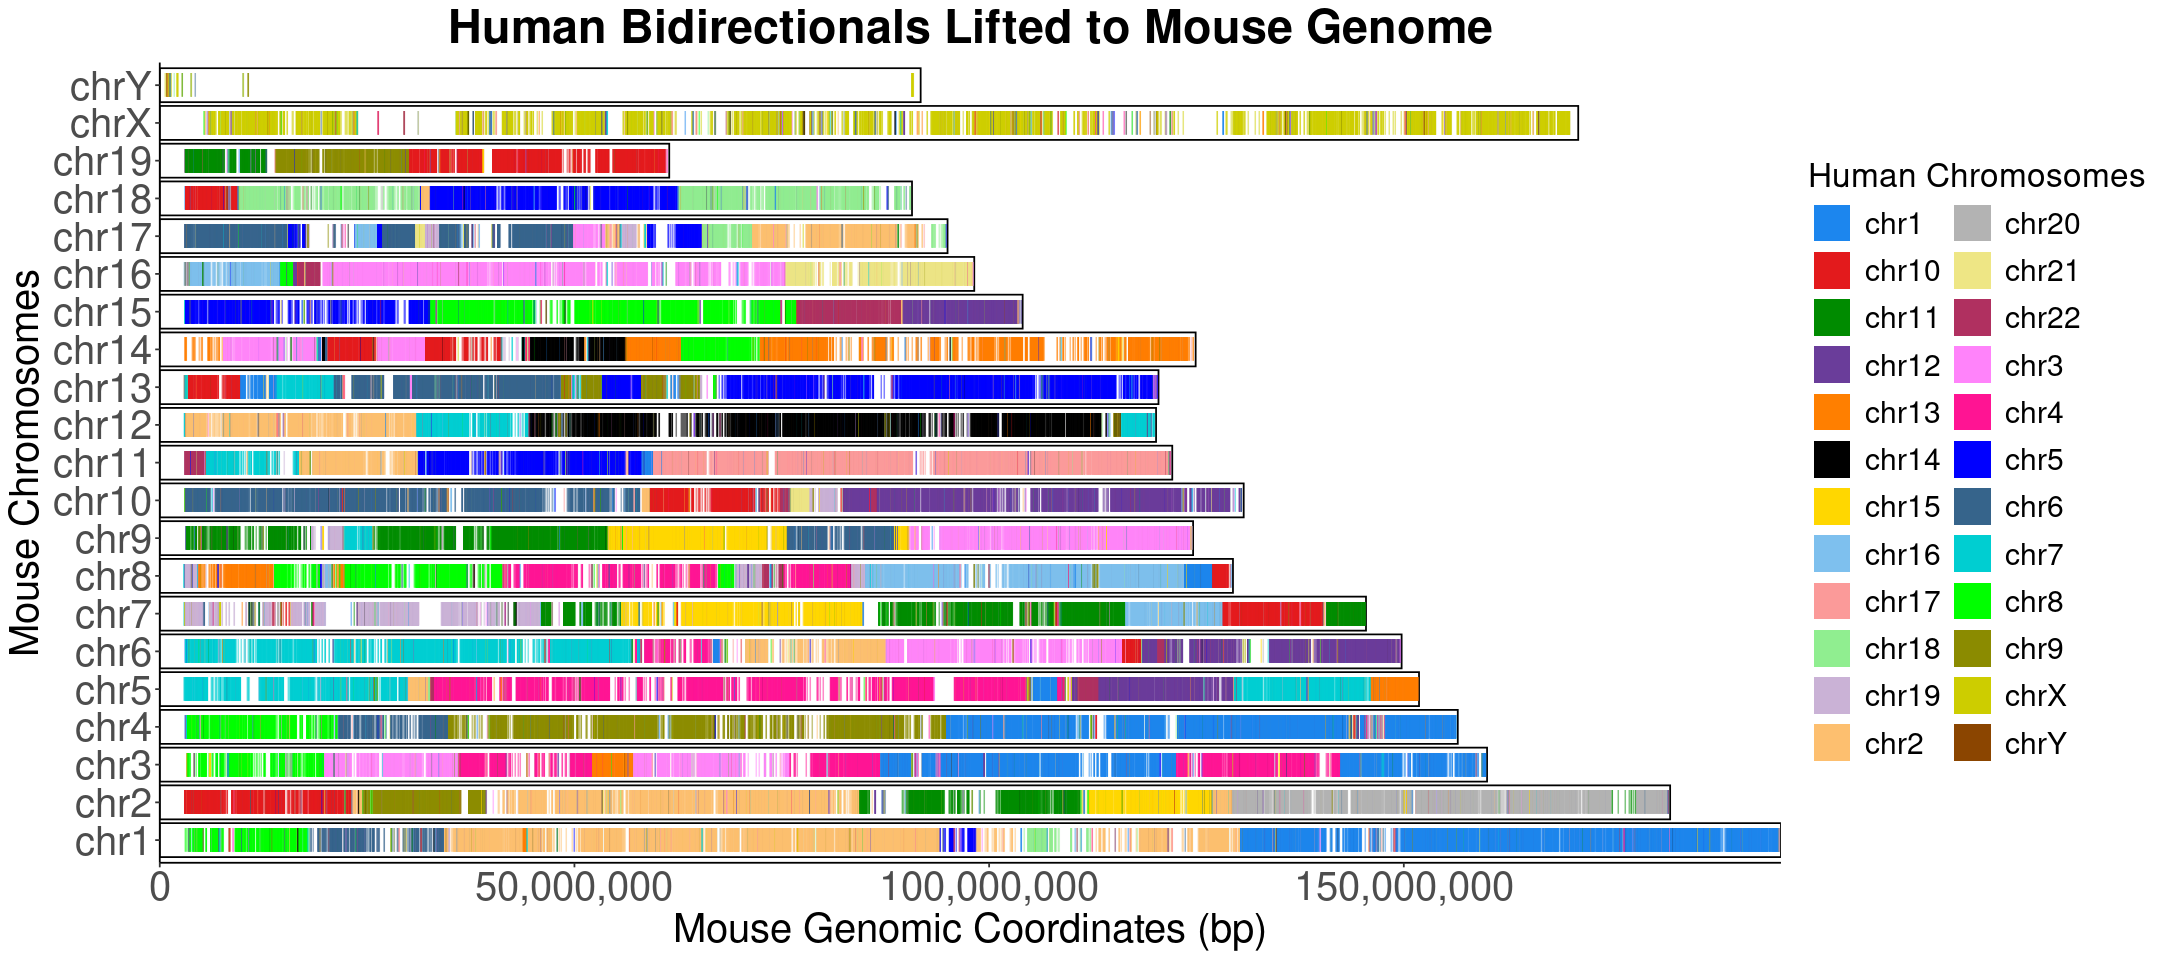

In [58]:
options(repr.plot.width=18, repr.plot.height=8)

mm10_bidirs_lifted_plot <- ggplot(data=mm10_chroms, 
       aes(y=chrs, x=V2)) +
geom_bar(stat="identity", fill = 'white', color='black') +
geom_point(data = mm10_bidirs_liftover_distances_long_within1kb_transcribed,
           aes(y = mm10_chrom, x = mm10_start, color=hg38_chrom), 
           shape=124, 
           #color='#5e3c99',#'orange',
           size=5, 
           alpha=0.5) +
xlab("Mouse Genomic Coordinates (bp)") +
ylab("Mouse Chromosomes") +
ggtitle("Human Bidirectionals Lifted to Mouse Genome") +
theme_classic() +
scale_x_continuous(expand = c(0, 0), 
                   labels = scales::comma) +
scale_color_manual(name = "Human Chromosomes",
                   values=colors25) +
theme(plot.title = element_text(hjust = 0.5, 
                                face = "bold",
                               size = 28),
      axis.title = element_text(size = 24), 
      axis.text = element_text(size = 24),
      axis.text.x = element_text(size = 24),
     legend.title = element_text(size = 20),
     legend.text = element_text(size = 18)) + 
guides(colour = guide_legend(override.aes = list(size=10, 
                                                 shape=15, 
                                                 alpha=1)))

mm10_bidirs_lifted_plot

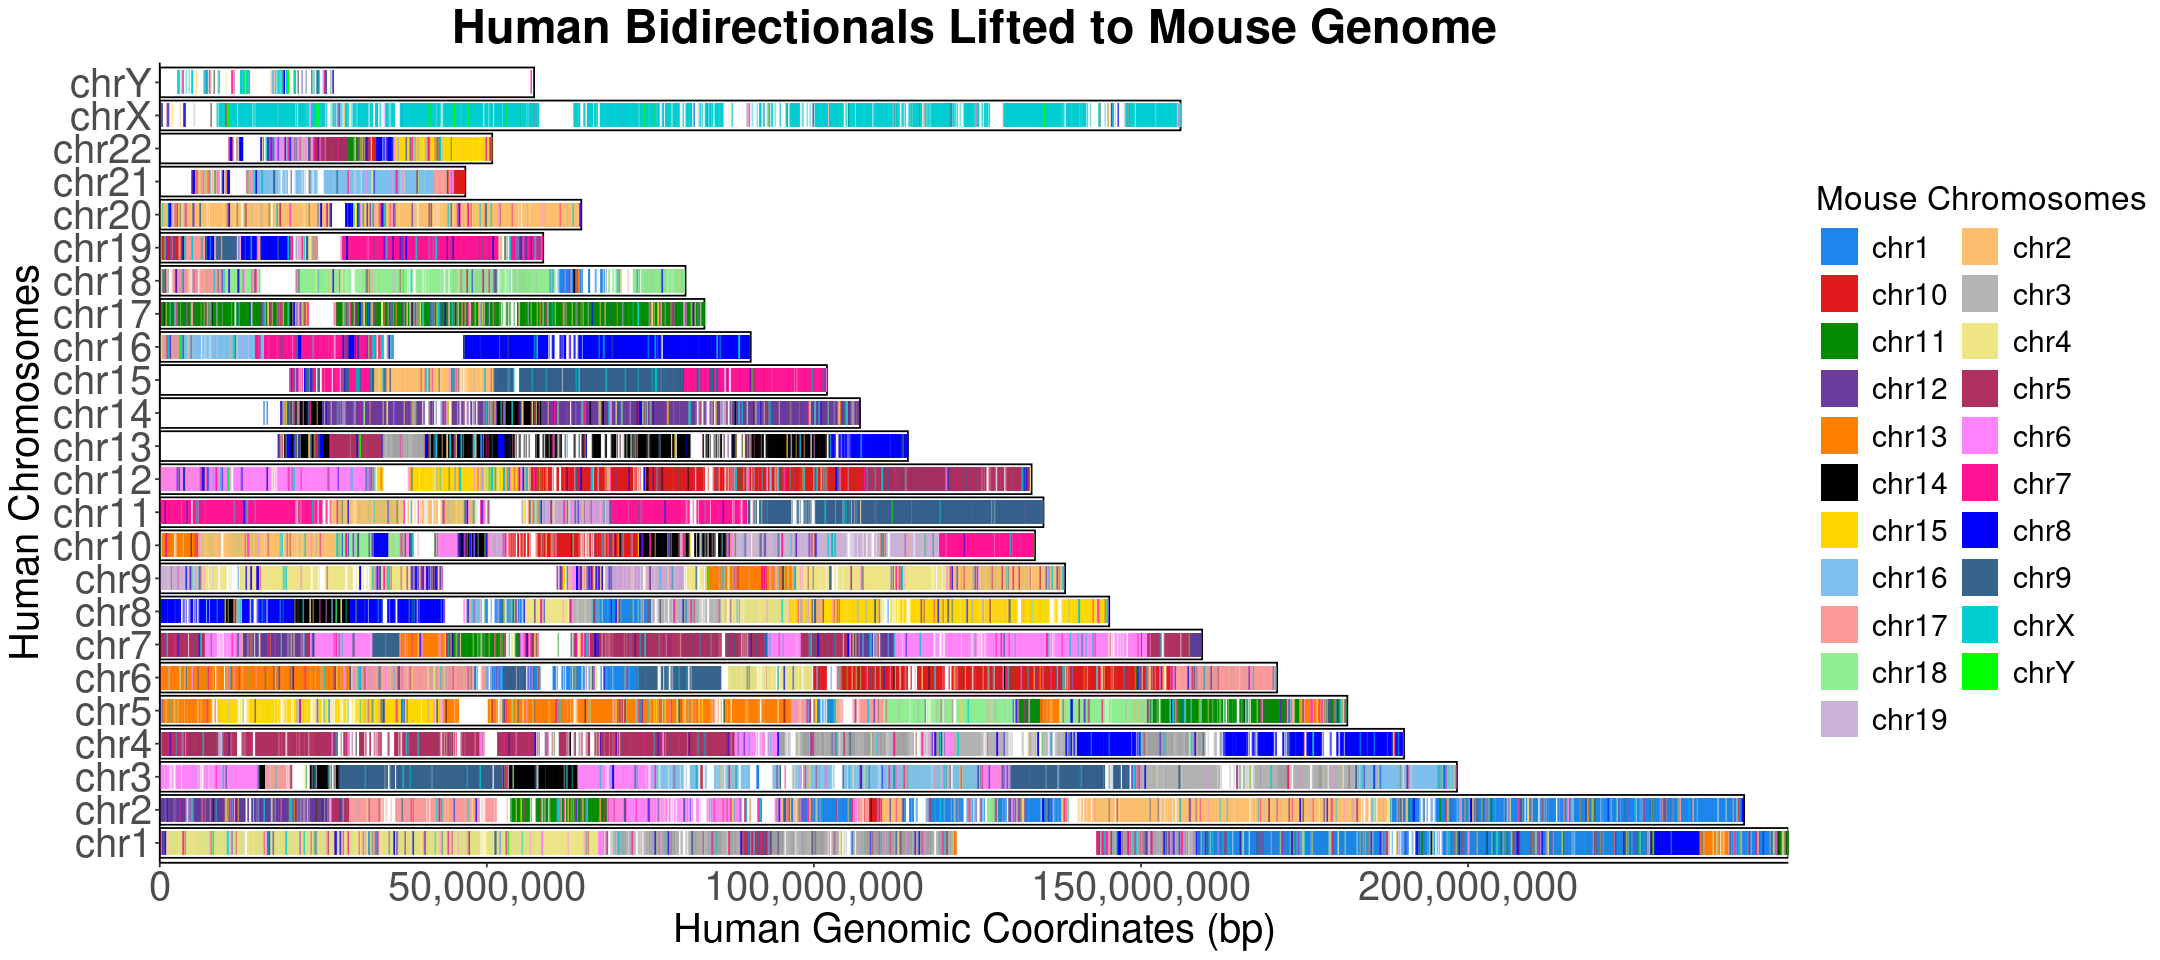

In [59]:
options(repr.plot.width=18, repr.plot.height=8)

mm10_bidirs_lifted_hg38_plot <- ggplot(data=hg38_chroms, 
       aes(y=chrs, x=V2)) +
geom_bar(stat="identity", fill = 'white', color='black') +
geom_point(data = mm10_bidirs_liftover_distances_long_within1kb_transcribed,
           aes(y = hg38_chrom, x = hg38_start, color=mm10_chrom), 
           shape=124, 
           #color='#5e3c99',#'orange',
           size=5, 
           alpha=0.5) +
xlab("Human Genomic Coordinates (bp)") +
ylab("Human Chromosomes") +
ggtitle("Human Bidirectionals Lifted to Mouse Genome") +
theme_classic() +
scale_x_continuous(expand = c(0, 0), 
                   labels = scales::comma) +
scale_color_manual(name = "Mouse Chromosomes",
                   values=colors25) +
theme(plot.title = element_text(hjust = 0.5, 
                                face = "bold",
                               size = 28),
      axis.title = element_text(size = 24), 
      axis.text = element_text(size = 24),
      axis.text.x = element_text(size = 24),
     legend.title = element_text(size = 20),
     legend.text = element_text(size = 18)) + 
guides(colour = guide_legend(override.aes = list(size=10, 
                                                 shape=15, 
                                                 alpha=1)))

mm10_bidirs_lifted_hg38_plot

# Conclusions

# Session information

In [60]:
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-pc-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /usr/lib64/libopenblasp-r0.3.3.so;  LAPACK version 3.8.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Denver
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] cowplot_1.1.3     ggplot2_3.5.1     data.table_1.16.2

loaded via a namespace (and not attached):
 [1] gtable_0.3.6      jsonlite_1.8.9    dplyr_1.1.4       compiler_4.4.0   
 [5] crayon_1.5.3      tidyselect_1.2.1  IRdisplay_1.1     textshaping_0.4.0
 [9] sy